In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [183]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [184]:
# cleaning data
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.strip()

df = df.replace("?", np.nan)

In [185]:
# separate features and target
X = df.drop("income", axis=1)
y = df["income"].copy()

y = y.replace({
    "<=50K": 0,
    ">50K": 1,
    "<=50K.": 0,
    ">50K.": 1
})

In [186]:
numeric_features = [
    "age", "fnlwgt", "education.num", "capital.gain",
    "capital.loss", "hours.per.week"
]

categorical_features = [
    "workclass", "education", "marital.status", "occupation",
    "relationship", "race", "sex", "native.country"
]

In [187]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_logistic = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", numeric_transformer_unscaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # classification report as table
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # confusion matrix as table
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(report_df)
    print("\nConfusion Matrix:")
    print(cm_df)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1 Score": f1
    }

results = []

In [189]:
X = df.drop("income", axis=1).copy()

y = df["income"].copy()
y = y.astype(str).str.strip()

y = y.map({
    "<=50K": 0,
    ">50K": 1,
    "<=50K.": 0,
    ">50K.": 1
})

y = pd.Series(y, dtype="int64")

print("y unique values:", y.unique())
print("y dtype:", y.dtype)
print("missing in y:", y.isna().sum())
print(y.head())

y unique values: [0 1]
y dtype: int64
missing in y: 0
0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64


In [190]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor_logistic),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

logistic_model.fit(X_train, y_train)
results.append(evaluate_model(logistic_model, X_test, y_test, "Logistic Regression"))

Logistic Regression
              precision    recall  f1-score      support
0              0.880825  0.932659  0.906001  4945.000000
1              0.739233  0.602041  0.663620  1568.000000
accuracy       0.853063  0.853063  0.853063     0.853063
macro avg      0.810029  0.767350  0.784811  6513.000000
weighted avg   0.846737  0.853063  0.847648  6513.000000

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0         4612          333
Actual 1          624          944


In [ ]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", DecisionTreeClassifier(random_state=42, max_depth=10))
])

decision_tree_model.fit(X_train, y_train)

results.append(evaluate_model(decision_tree_model, X_test, y_test, "Decision Tree"))

Decision Tree
              precision    recall  f1-score      support
0              0.873182  0.946815  0.908509  4945.000000
1              0.771503  0.566327  0.653181  1568.000000
accuracy       0.855213  0.855213  0.855213     0.855213
macro avg      0.822342  0.756571  0.780845  6513.000000
weighted avg   0.848703  0.855213  0.847039  6513.000000

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0         4682          263
Actual 1          680          888


In [193]:
dt_preprocessor = decision_tree_model.named_steps["preprocessor"]
dt_classifier = decision_tree_model.named_steps["classifier"]

dt_feature_names = dt_preprocessor.get_feature_names_out()
dt_importances = dt_classifier.feature_importances_

dt_importance_df = pd.DataFrame({
    "Feature": dt_feature_names,
    "Importance": dt_importances
}).sort_values(by="Importance", ascending=False)

dt_importance_df.head(15)

,Feature,Importance
32,cat__marital.status_Married-civ-spouse,0.382899
2,num__education.num,0.205705
3,num__capital.gain,0.190046
4,num__capital.loss,0.067880
0,num__age,0.047715
5,num__hours.per.week,0.032854
1,num__fnlwgt,0.016886
40,cat__occupation_Exec-managerial,0.009803
56,cat__relationship_Wife,0.006217
11,cat__workclass_Self-emp-not-inc,0.004493


In [ ]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=15
    ))
])

random_forest_model.fit(X_train, y_train)

results.append(evaluate_model(random_forest_model, X_test, y_test, "Random Forest"))

Random Forest
              precision    recall  f1-score      support
0              0.872565  0.951264  0.910217  4945.000000
1              0.785205  0.561862  0.655019  1568.000000
accuracy       0.857516  0.857516  0.857516     0.857516
macro avg      0.828885  0.756563  0.782618  6513.000000
weighted avg   0.851533  0.857516  0.848778  6513.000000

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0         4704          241
Actual 1          687          881


In [195]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]

rf_feature_names = rf_preprocessor.get_feature_names_out()
rf_importances = rf_classifier.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

rf_importance_df.head(15)

,Feature,Importance
3,num__capital.gain,0.153047
32,cat__marital.status_Married-civ-spouse,0.107828
2,num__education.num,0.095347
51,cat__relationship_Husband,0.086133
0,num__age,0.076181
5,num__hours.per.week,0.053633
34,cat__marital.status_Never-married,0.047828
4,num__capital.loss,0.040229
1,num__fnlwgt,0.034816
40,cat__occupation_Exec-managerial,0.026471


In [196]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df


,Model,Accuracy,F1 Score
0,Random Forest,0.857516,0.655019


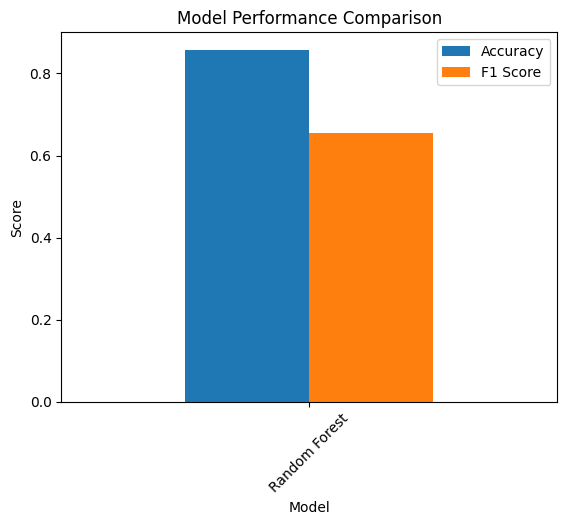

In [197]:
results_df.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()